# SaaS Customer Churn — Exploratory Data Analysis

**Goal:** Understand the structure of the Telco churn dataset, identify
the overall churn rate, and surface the key drivers of churn before
any modeling.

**Dataset:** IBM Watson Telco Customer Churn — 7,043 customers, 21 features

**Author:** Saee Joshi

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot styling
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('muted')

print("Imports done")

Imports done


## 1. Load and inspect the data

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv')

print(f"Shape: {df.shape}")
print(f"\nColumns:\n{df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")
df.head()

Shape: (7043, 21)

Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing values:
customerID      

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Data quality fixes

TotalCharges is loaded as object type due to whitespace strings
for new customers with zero tenure. We fix this before any analysis.

In [3]:
# Fix TotalCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print(f"NaN in TotalCharges after fix: {df['TotalCharges'].isnull().sum()}")

# New customers with tenure=0, safe to fill with 0
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Convert Churn to binary integer
df['Churn_Binary'] = (df['Churn'] == 'Yes').astype(int)

print(f"Churn value counts:\n{df['Churn'].value_counts()}")
print(f"\nData types after fix:\n{df[['TotalCharges','Churn_Binary']].dtypes}")

NaN in TotalCharges after fix: 11
Churn value counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Data types after fix:
TotalCharges    float64
Churn_Binary      int64
dtype: object


## 3. Overall churn rate

Overall churn rate: 26.5%
Retained: 5,174
Churned: 1,869


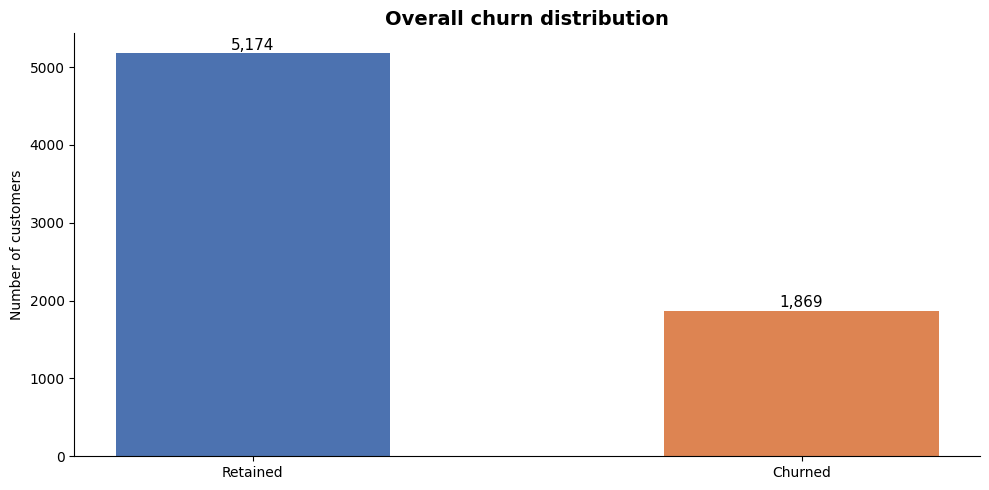

In [4]:
churn_rate = df['Churn_Binary'].mean()
churn_counts = df['Churn'].value_counts()

print(f"Overall churn rate: {churn_rate:.1%}")
print(f"Retained: {churn_counts['No']:,}")
print(f"Churned: {churn_counts['Yes']:,}")

fig, ax = plt.subplots()
ax.bar(['Retained', 'Churned'], churn_counts.values,
       color=['#4C72B0', '#DD8452'], width=0.5)
ax.set_title('Overall churn distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of customers')

for i, v in enumerate(churn_counts.values):
    ax.text(i, v + 50, f'{v:,}', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Churn by contract type

**Hypothesis:** Month-to-month customers churn at a significantly
higher rate than annual or two-year subscribers.

Churn rate by contract type:
  Month-to-month: 42.7%
  One year: 11.3%
  Two year: 2.8%


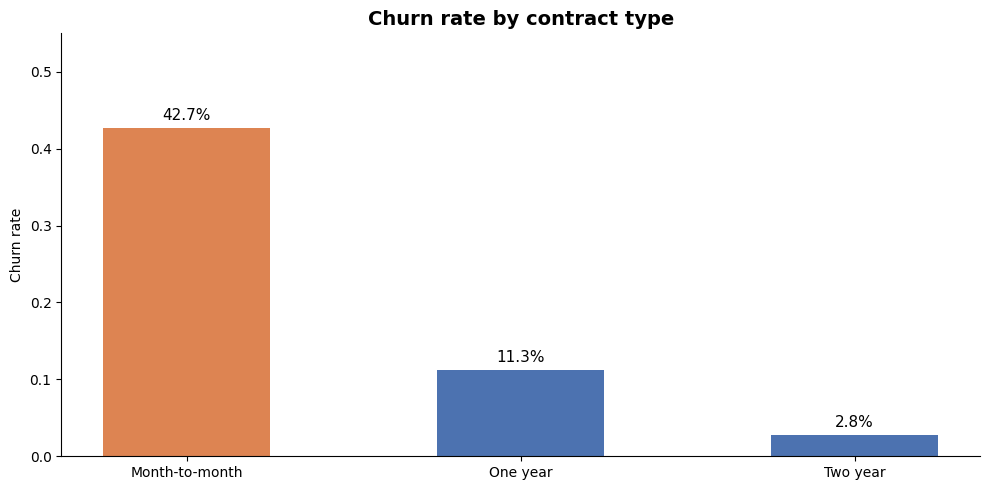

In [5]:
contract_churn = df.groupby('Contract')['Churn_Binary'].mean().sort_values(ascending=False)

print("Churn rate by contract type:")
for contract, rate in contract_churn.items():
    print(f"  {contract}: {rate:.1%}")

fig, ax = plt.subplots()
colors = ['#DD8452' if i == 0 else '#4C72B0' for i in range(len(contract_churn))]
bars = ax.bar(contract_churn.index, contract_churn.values, color=colors, width=0.5)
ax.set_title('Churn rate by contract type', fontsize=14, fontweight='bold')
ax.set_ylabel('Churn rate')
ax.set_ylim(0, 0.55)

for bar, val in zip(bars, contract_churn.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
            f'{val:.1%}', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('churn_by_contract.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Churn by customer tenure

**Hypothesis:** Newer customers are at higher churn risk.
Customers who stay past 24 months are likely committed long-term.

Churn rate by tenure group:
  0-12 months: 47.7%
  13-24 months: 28.7%
  25-48 months: 20.4%
  49-72 months: 9.5%


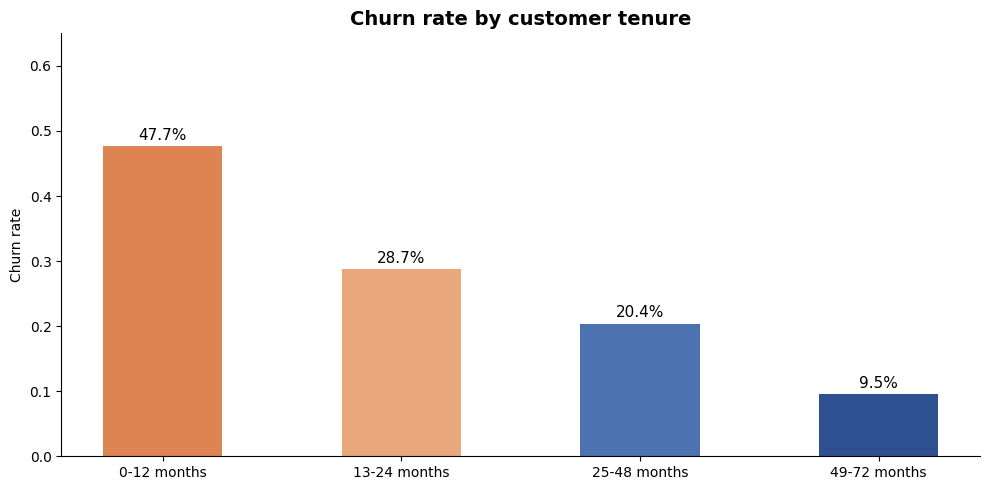

In [6]:
df['Tenure_Group'] = pd.cut(df['tenure'],
                             bins=[0, 12, 24, 48, 72],
                             labels=['0-12 months', '13-24 months',
                                     '25-48 months', '49-72 months'])

tenure_churn = df.groupby('Tenure_Group', observed=True)['Churn_Binary'].mean()

print("Churn rate by tenure group:")
for group, rate in tenure_churn.items():
    print(f"  {group}: {rate:.1%}")

fig, ax = plt.subplots()
colors = ['#DD8452', '#E8A87C', '#4C72B0', '#2E5090']
bars = ax.bar(tenure_churn.index, tenure_churn.values, color=colors, width=0.5)
ax.set_title('Churn rate by customer tenure', fontsize=14, fontweight='bold')
ax.set_ylabel('Churn rate')
ax.set_ylim(0, 0.65)

for bar, val in zip(bars, tenure_churn.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
            f'{val:.1%}', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('churn_by_tenure.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Churn by support and security services

**Hypothesis:** Customers without protective services
(tech support, online security) churn at higher rates —
these services may increase switching costs and perceived value.

TechSupport:
  No: 41.6%
  Yes: 15.2%

OnlineSecurity:
  No: 41.8%
  Yes: 14.6%

OnlineBackup:
  No: 39.9%
  Yes: 21.5%

DeviceProtection:
  No: 39.1%
  Yes: 22.5%



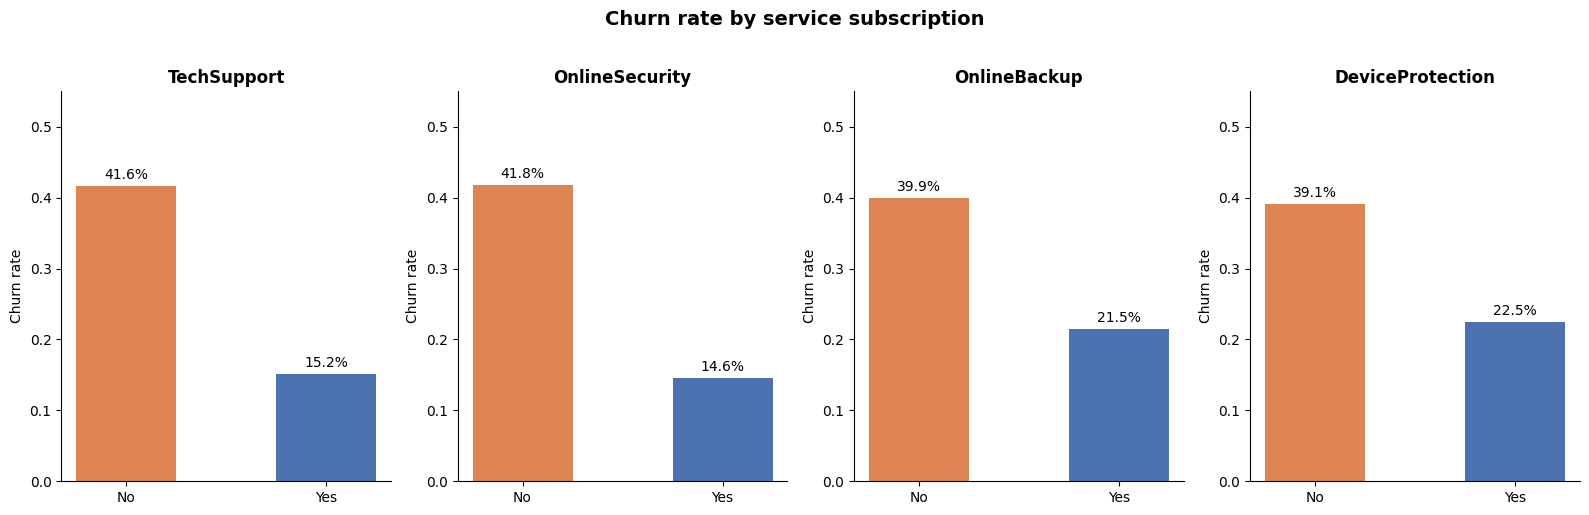

In [7]:
services = ['TechSupport', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection']

fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for ax, service in zip(axes, services):
    filtered = df[df[service] != 'No internet service']
    rates = filtered.groupby(service)['Churn_Binary'].mean()

    colors = ['#DD8452' if x == 'No' else '#4C72B0' for x in rates.index]
    bars = ax.bar(rates.index, rates.values, color=colors, width=0.5)
    ax.set_title(service, fontsize=12, fontweight='bold')
    ax.set_ylabel('Churn rate')
    ax.set_ylim(0, 0.55)

    for bar, val in zip(bars, rates.values):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
                f'{val:.1%}', ha='center', fontsize=10)

    print(f"{service}:")
    for label, val in rates.items():
        print(f"  {label}: {val:.1%}")
    print()

plt.suptitle('Churn rate by service subscription',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('churn_by_services.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Churn by payment method

**Hypothesis:** Electronic check customers churn at higher rates —
this payment method requires active renewal and attracts
less committed customers.

Churn rate by payment method:
  Electronic check: 45.3%
  Mailed check: 19.1%
  Bank transfer (automatic): 16.7%
  Credit card (automatic): 15.2%


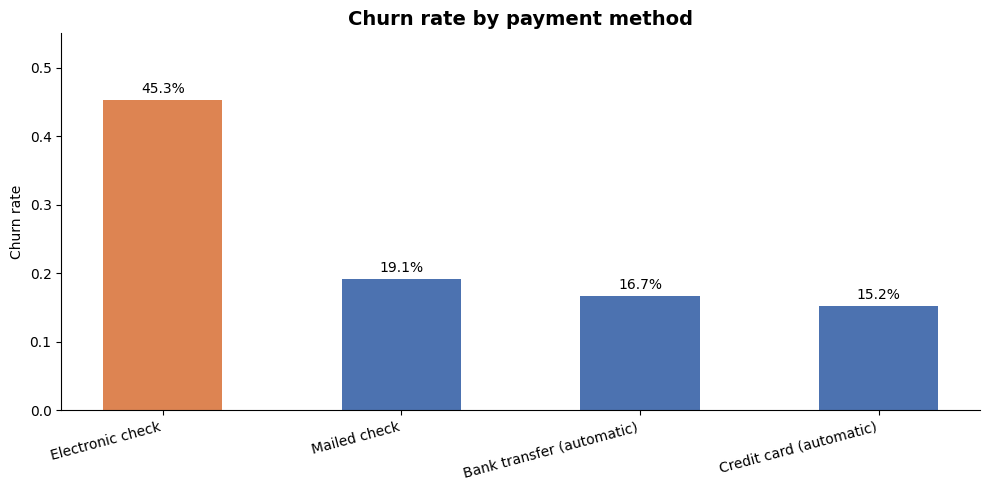

In [9]:
payment_churn = df.groupby('PaymentMethod')['Churn_Binary'].mean().sort_values(ascending=False)

print("Churn rate by payment method:")
for method, rate in payment_churn.items():
    print(f"  {method}: {rate:.1%}")

fig, ax = plt.subplots()
colors = ['#DD8452' if i == 0 else '#4C72B0' for i in range(len(payment_churn))]
bars = ax.bar(payment_churn.index, payment_churn.values, color=colors, width=0.5)
ax.set_title('Churn rate by payment method', fontsize=14, fontweight='bold')
ax.set_ylabel('Churn rate')
ax.set_ylim(0, 0.55)
ax.set_xticks(range(len(payment_churn)))
ax.set_xticklabels(payment_churn.index, rotation=15, ha='right')

for bar, val in zip(bars, payment_churn.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
            f'{val:.1%}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('churn_by_payment.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Key findings from EDA

| Finding | Detail |
|---------|--------|
| Overall churn rate | 26.5% — roughly 1 in 4 customers leaves |
| Contract type | Month-to-month customers churn at 42.7% vs 2.8% for two-year — a 15x difference |
| Tenure | Customers in their first 12 months churn at 47.7%, dropping to 9.5% after 49 months |
| Tech support | Customers without tech support churn at 41.6% vs 15.2% with it — nearly 3x |
| Online security | Customers without online security churn at 41.8% vs 14.6% with it — nearly 3x |
| Payment method | Electronic check customers churn at 45.3% vs ~16% for automatic payments |

**Takeaway:** Churn is heavily concentrated in a predictable high-risk profile —
month-to-month contract, first 12 months of tenure, no protective services,
paying by electronic check. This profile will drive our feature engineering in notebook 02.

**Next:** Feature engineering — convert these findings into model-ready features.